<a href="https://colab.research.google.com/github/colinskinzi/GCP-Project---SDG-2_-Zero-Hunger/blob/main/Breakdown_of_Producer_Income_and_Productivity_in_various_African_nations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from google.colab import files
uploaded= files.upload()
#read dataset
df= pd.read_excel("Copy of SDG_CLEAN_DATA.xlsx")
print(df.info())
print(df)

Saving Copy of SDG_CLEAN_DATA.xlsx to Copy of SDG_CLEAN_DATA (1).xlsx
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Index                   72 non-null     object 
 1   SME_Size                72 non-null     object 
 2   Countries               72 non-null     object 
 3   Gender                  72 non-null     object 
 4   Producers_Productivity  72 non-null     float64
 5   Avg_income_SMEs         72 non-null     float64
dtypes: float64(2), object(4)
memory usage: 3.5+ KB
None
     Index   SME_Size      Countries    Gender  Producers_Productivity  \
0     C7_7  Large SME   Burkina Faso  Both sex                    8.09   
1       A1  Small SME  Côte d'Ivoire    Female                   11.85   
2   A11_11  Large SME          Niger    Female                   10.25   
3     C4_4  Large SME          Benin  Both sex     

**Summary Stats**

In [ ]:
summary= df.groupby(['Countries','SME_Size','Gender']).agg({"Avg_income_SMEs": ['mean','median','std','count'], "Producers_Productivity": ['mean','median','std']})
print("Summary Stats:")
display(summary)

Summary Stats:


Avg_income_SMEs               \
                                                          mean   median std   
Countries                   SME_Size  Gender                                  
Benin                       Large SME Both sex         5377.97  5377.97 NaN   
                                      Female           3085.93  3085.93 NaN   
                                      Male             5473.97  5473.97 NaN   
                            Small SME Both sex          868.51   868.51 NaN   
                                      Female            461.31   461.31 NaN   
...                                                        ...      ...  ..   
United Republic of Tanzania Large SME Female           1191.47  1191.47 NaN   
                                      Male             1505.23  1505.23 NaN   
                            Small SME Both sex          438.94   438.94 NaN   
                                      Female            306.03   306.03 NaN   
                                      Male              494.43   494.43 NaN   

                                                     Producers_Productivity  \
                                               count                   mean   
Countries                   SME_Size  Gender                                  
Benin                       Large SME Both sex     1                  23.27   
                                      Female       1                  26.28   
                                      Male         1                  23.14   
                            Small SME Both sex     1                  12.30   
                                      Female       1                  11.58   
...                                              ...                    ...   
United Republic of Tanzania Large SME Female       1                   9.92   
                                      Male         1                   6.79   
                            Small SME Both sex     1                   4.35   
                                      Female       1                   4.30   
                                      Male         1                   4.38   

                                                           
                                               median std  
Countries                   SME_Size  Gender               
Benin                       Large SME Both sex  23.27 NaN  
                                      Female    26.28 NaN  
                                      Male      23.14 NaN  
                            Small SME Both sex  12.30 NaN  
                                      Female    11.58 NaN  
...                                               ...  ..  
United Republic of Tanzania Large SME Female     9.92 NaN  
                                      Male       6.79 NaN  
                            Small SME Both sex   4.35 NaN  
                                      Female     4.30 NaN  
                                      Male       4.38 NaN  

[72 rows x 7 columns]

**Key Relationships**

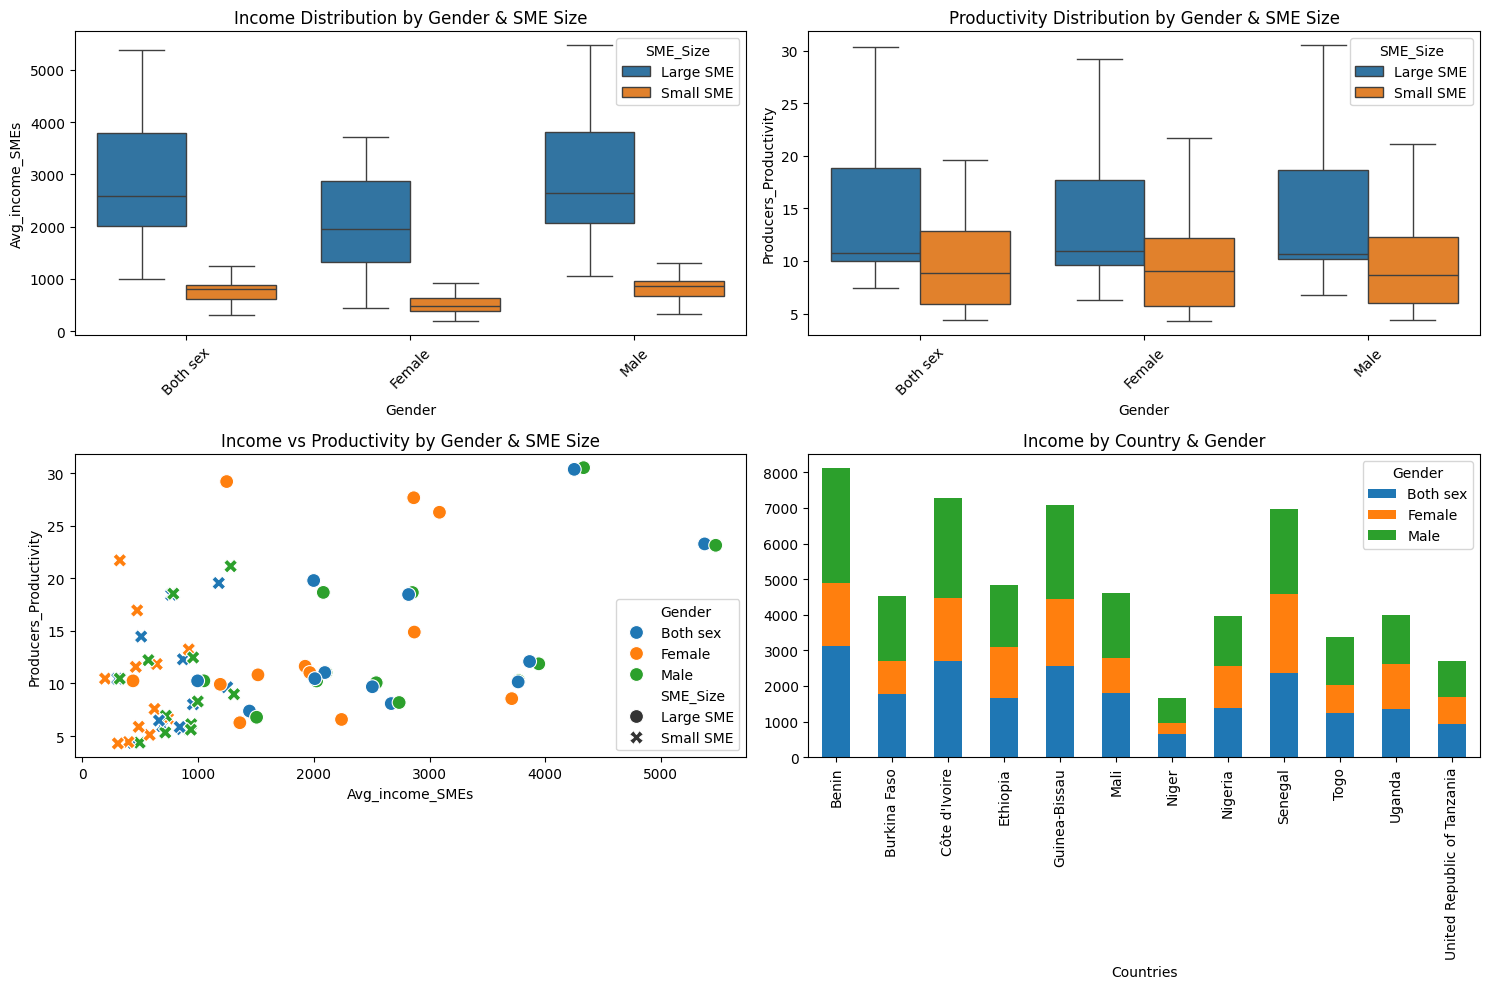

In [ ]:
plt.figure(figsize=(15,10))

#Income distribution by Gender and SME Size
plt.subplot(2,2,1)
sns.boxplot(x="Gender", y="Avg_income_SMEs", hue="SME_Size", data=df)
plt.title('Income Distribution by Gender & SME Size')
plt.xticks(rotation=45)

#Productivity distribution
plt.subplot(2,2,2)
sns.boxplot(x="Gender", y= "Producers_Productivity", hue="SME_Size", data=df)
plt.title('Productivity Distribution by Gender & SME Size')
plt.xticks(rotation=45)

#Income vs Productivity
plt.subplot(2,2,3)
sns.scatterplot(x="Avg_income_SMEs", y= "Producers_Productivity", hue= "Gender", style= "SME_Size", data=df, s=100)
plt.title('Income vs Productivity by Gender & SME Size')

#Country-Level Comparisons
plt.subplot(2,2,4)
country_plot= df.groupby(["Countries", "Gender"])["Avg_income_SMEs"].mean().unstack()
country_plot.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Income by Country & Gender')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


**Gap Analysis and Policy Implications**

In [ ]:
#Calculating comprehensive gap metrics
gap_analysis= df.pivot_table(index=["Countries", "SME_Size"], columns="Gender", values=["Avg_income_SMEs", "Producers_Productivity"], aggfunc='mean')

#Calculating ratios
gap_analysis[("income_ratio", "Female/Male")] = gap_analysis[("Avg_income_SMEs", "Female")]/gap_analysis[("Avg_income_SMEs", "Male")]
gap_analysis[("productivity_ratio", "Female/Male")] = gap_analysis[("Producers_Productivity", "Female")]/gap_analysis[("Producers_Productivity", "Male")]
gap_analysis[("income_ratio", "Both sex/Male")] = gap_analysis[("Avg_income_SMEs", "Both sex")]/gap_analysis[("Avg_income_SMEs", "Male")]

#Sort and Display
gap_analysis = gap_analysis.sort_values(("income_ratio", "Female/Male"))
print("Comprehensive Gap Analysis:")
display(gap_analysis)

Comprehensive Gap Analysis:


Avg_income_SMEs                    \
Gender                                       Both sex   Female     Male   
Countries                   SME_Size                                      
Niger                       Large SME          995.30   436.99  1049.51   
Benin                       Small SME          868.51   461.31   956.51   
Burkina Faso                Large SME         2669.11  1360.58  2737.47   
Côte d'Ivoire               Small SME         1178.46   641.81  1280.84   
Burkina Faso                Small SME          860.32   486.43   937.27   
Mali                        Large SME         2819.07  1517.08  2851.88   
Nigeria                     Small SME          661.62   397.44   721.64   
Benin                       Large SME         5377.97  3085.93  5473.97   
Togo                        Small SME          507.82   323.26   569.73   
                            Large SME         1998.69  1246.48  2082.10   
Mali                        Small SME          766.85   473.08   785.53   
Niger                       Small SME          301.58   195.53   322.21   
Ethiopia                    Small SME          840.98   580.94   940.03   
United Republic of Tanzania Small SME          438.94   306.03   494.43   
Côte d'Ivoire               Large SME         4250.98  2863.62  4331.72   
Guinea-Bissau               Small SME         1251.39   918.62  1309.71   
                            Large SME         3864.98  2868.44  3944.38   
Senegal                     Small SME          954.90   739.85   997.00   
United Republic of Tanzania Large SME         1443.76  1191.47  1505.23   
Uganda                      Small SME          691.00   623.00   716.00   
Ethiopia                    Large SME         2505.83  2239.37  2539.25   
Nigeria                     Large SME         2094.78  1965.33  2105.30   
Uganda                      Large SME         2009.00  1925.00  2024.00   
Senegal                     Large SME         3766.25  3710.88  3770.56   

                                      Producers_Productivity                \
Gender                                              Both sex Female   Male   
Countries                   SME_Size                                         
Niger                       Large SME                  10.25  10.25  10.25   
Benin                       Small SME                  12.30  11.58  12.47   
Burkina Faso                Large SME                   8.09   6.27   8.19   
Côte d'Ivoire               Small SME                  19.55  11.85  21.15   
Burkina Faso                Small SME                   5.66   5.88   5.61   
Mali                        Large SME                  18.46  10.82  18.65   
Nigeria                     Small SME                   6.48   4.43   6.93   
Benin                       Large SME                  23.27  26.28  23.14   
Togo                        Small SME                  14.46  21.71  12.22   
                            Large SME                  19.79  29.20  18.66   
Mali                        Small SME                  18.44  16.95  18.54   
Niger                       Small SME                  10.46  10.46  10.46   
Ethiopia                    Small SME                   5.86   5.12   6.13   
United Republic of Tanzania Small SME                   4.35   4.30   4.38   
Côte d'Ivoire               Large SME                  30.36  27.66  30.52   
Guinea-Bissau               Small SME                   9.64  13.24   8.98   
                            Large SME                  12.09  14.89  11.87   
Senegal                     Small SME                   8.02   6.67   8.29   
United Republic of Tanzania Large SME                   7.38   9.92   6.79   
Uganda                      Small SME                   5.95   7.58   5.34   
Ethiopia                    Large SME                   9.69   6.58  10.07   
Nigeria                     Large SME                  11.04  11.04  11.04   
Uganda                      Large SME                  10.46  

**Policy Simulations: Impact of Hypothetical Interventions**

In [ ]:
#Creating simulation scenarios
scenarios = {'baseline': df.copy(), 'income_increase': df.copy(), 'productivity_training': df.copy()}

# Define and fit the interaction model
interaction_model = smf.ols("Producers_Productivity ~ Q('Avg_income_SMEs') * Gender * SME_Size", data=df).fit()
# Print the model summary
#print(interaction_model.summary())

#scenario 1: 15% income increase for female-led SMEs (simulating policies like grants, subsidies or better market access)
scenarios['income_increase'].loc[(scenarios['income_increase']['Gender']=='Female'), "Avg_income_SMEs"] *=1.15

#scenario 2: 10% productivity increase for female-led SMEs(simulating training programs or technology adoption)
scenarios['productivity_training'].loc[(scenarios['productivity_training']['Gender']=='Female')& (scenarios['productivity_training']['SME_Size']=='Small SME'), "Producers_Productivity"] *=1.10


#predicting outcomes
for name, scenario in scenarios.items():
  if name != 'baseline':
    scenario['predicted_productivity'] = interaction_model.predict(scenario)

#calculating impact
impact_analysis = pd.DataFrame()
for name, scenario in scenarios.items():
  if name != 'baseline':
    impact= scenario.groupby(['Gender', 'SME_Size'])['predicted_productivity'].mean() -\
    scenarios['baseline'].groupby(['Gender', 'SME_Size'])["Producers_Productivity"].mean()
    impact_analysis[name]=impact

print('Policy Impact Analysis:')
display(impact_analysis)

Policy Impact Analysis:


income_increase  productivity_training
Gender   SME_Size                                         
Both sex Large SME    -1.984191e-12          -1.984191e-12
         Small SME    -1.597655e-11          -1.597655e-11
Female   Large SME     5.853299e-01          -6.890488e-12
         Small SME    -1.022206e-01           1.898925e-12
Male     Large SME    -4.376943e-12          -4.376943e-12
         Small SME    -2.771117e-12          -2.771117e-12

In [ ]:
#Loading AOI File
from google.colab import files
uploaded= files.upload()
aoi_df=pd.read_excel("AOI_Data.xlsx")
print("\nAOI dataset Overview:")
print(aoi_df.info())
print(aoi_df)

Saving AOI_Data.xlsx to AOI_Data (1).xlsx

AOI dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Countries  12 non-null     object 
 1   AOI        12 non-null     float64
dtypes: float64(1), object(1)
memory usage: 324.0+ bytes
None
                      Countries   AOI
0   United Republic of Tanzania  0.05
1                         Niger  0.13
2                 Guinea-Bissau  0.17
3                CÃ´te d'Ivoire  0.11
4                      Ethiopia  0.10
5                         Benin  0.12
6                          Mali  0.25
7                        Uganda  0.14
8                          Togo  0.22
9                       Nigeria  0.14
10                 Burkina Faso  0.19
11                      Senegal  0.26


In [ ]:
aoi_df=pd.read_excel("AOI_Data.xlsx")
print("\nAOI dataset Overview:")
print(aoi_df.info())

df["Countries"] = df["Countries"].str.strip().str.title()
aoi_df["Countries"] = aoi_df["Countries"].str.strip().str.title()

#Merging the two files
merged_df= pd.merge(df, aoi_df[["Countries", "AOI"]], left_on="Countries", right_on="Countries", how="left" )

print(f"Merged dataset shape: {merged_df.shape}")
print(f"Countries with AOI data: {merged_df['AOI'].notnull().sum()} records")
print(merged_df.head(10))


AOI dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Countries  12 non-null     object 
 1   AOI        12 non-null     float64
dtypes: float64(1), object(1)
memory usage: 324.0+ bytes
None
Merged dataset shape: (72, 7)
Countries with AOI data: 66 records
    Index   SME_Size                    Countries    Gender  \
0    C7_7  Large SME                 Burkina Faso  Both sex   
1      A1  Small SME                Côte D'Ivoire    Female   
2  A11_11  Large SME                        Niger    Female   
3    C4_4  Large SME                        Benin  Both sex   
4      B5  Small SME                     Ethiopia      Male   
5      C3  Small SME                      Senegal  Both sex   
6      C6  Small SME                       Uganda  Both sex   
7     C10  Small SME  United Republic Of Tanzania  Both sex   
8    A7_7  Large SME

**Income Disparity Analysis**

In [ ]:
#Calculating within-country income disparities
income_disparity = merged_df.groupby("Countries").agg({'Avg_income_SMEs': ['mean', 'std', lambda x: x.std()/x.mean()]}).round(3)

income_disparity.columns = ['mean_income', 'income_std', 'income_cv']
income_disparity = income_disparity.sort_values('income_cv', ascending=False)

print("Income Disparity by Country(Coefficient of Variation):")
print(income_disparity)
#0.5+ means high disparity of incomes in a country which means targeted interventions are necessary

Income Disparity by Country(Coefficient of Variation):
                             mean_income  income_std  income_cv
Countries                                                      
Benin                           2704.033    2298.744      0.850
Togo                            1121.347     777.956      0.694
Mali                            1535.582    1064.214      0.693
Niger                            550.187     374.118      0.680
Senegal                         2323.240    1564.669      0.673
Côte D'Ivoire                   2424.572    1625.109      0.670
Burkina Faso                    1508.530     966.471      0.641
Nigeria                         1324.352     809.436      0.611
United Republic Of Tanzania      896.643     543.457      0.606
Guinea-Bissau                   2359.587    1374.295      0.582
Ethiopia                        1607.733     912.284      0.567
Uganda                          1331.333     718.590      0.540


**Government Support Analysis**

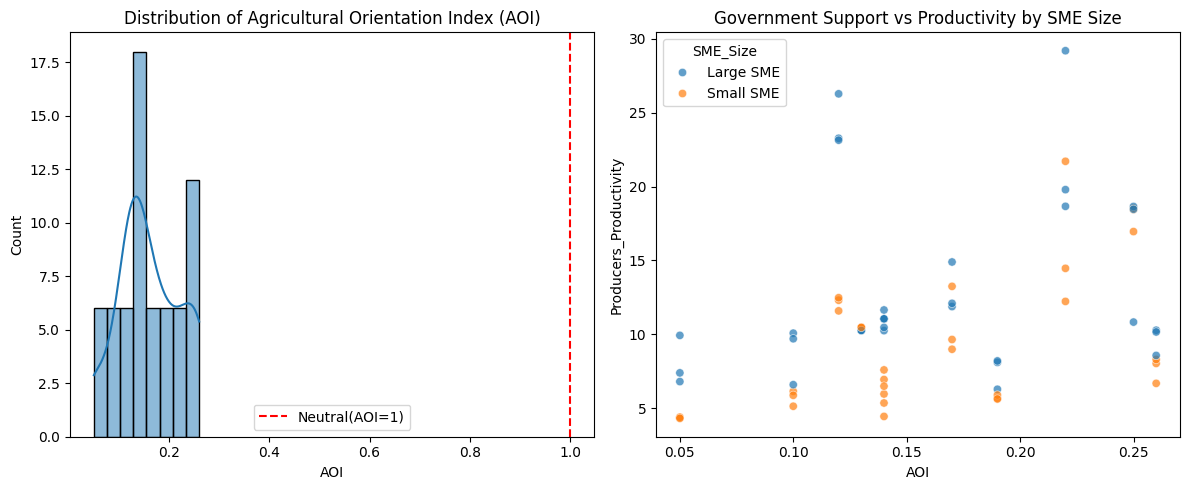

In [ ]:
#Analyzing AOI distribution and relationship with productivity
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(merged_df['AOI'].dropna(), kde=True)
plt.title("Distribution of Agricultural Orientation Index (AOI)") #Shows under prioritization (less than 1) of agriculture by government, usually measured against GDP distribution
plt.axvline(1, color='red', linestyle='--', label='Neutral(AOI=1)')
plt.legend()

plt.subplot(1,2,2)
sns.scatterplot(x='AOI', y='Producers_Productivity', hue='SME_Size', data=merged_df, alpha=0.7) #Do you think there's big difference between productivity for high governement funded SMEs?
plt.title("Government Support vs Productivity by SME Size")

plt.tight_layout()
plt.show()

**Statistical Modeling**

In [ ]:
#Enhanced regression model to understand what factors drive agricultural productivity among SMEs, with special attention to how income disparities and govt support interact with other variables
model= smf.ols('''Producers_Productivity ~ Avg_income_SMEs + C(Gender) + AOI + Avg_income_SMEs:C(Gender) + Avg_income_SMEs:C(SME_Size) + AOI:C(SME_Size) + C(Countries)''',
               data=merged_df.dropna(subset=['AOI'])).fit()

print("Comprehensive Productivity Model:")
print(model.summary())



Comprehensive Productivity Model:
                              OLS Regression Results                              
Dep. Variable:     Producers_Productivity   R-squared:                       0.825
Model:                                OLS   Adj. R-squared:                  0.764
Method:                     Least Squares   F-statistic:                     13.35
Date:                    Sun, 07 Sep 2025   Prob (F-statistic):           8.65e-13
Time:                            13:07:56   Log-Likelihood:                -148.78
No. Observations:                      66   AIC:                             333.6
Df Residuals:                          48   BIC:                             373.0
Df Model:                              17                                         
Covariance Type:                nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
------------------------

**Income Disparity Impact Analyis**

In [ ]:
# Calculating productivity gaps across income quartiles
merged_df['income_quartile'] = pd.qcut(
    merged_df['Avg_income_SMEs'],
    q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

productivity_by_income = merged_df.groupby(['income_quartile', 'SME_Size']).agg({
    'Producers_Productivity': ['mean', 'std', 'count']
}).round(2)

print("Productivity by Income Quartile and SME Size:")
print(productivity_by_income)

Productivity by Income Quartile and SME Size:
                          Producers_Productivity            
                                            mean   std count
income_quartile SME_Size                                    
Q1 (Lowest)     Large SME                  10.25   NaN     1
                Small SME                   9.57  5.00    17
Q2              Large SME                  10.25  0.00     2
                Small SME                   9.94  5.12    16
Q3              Large SME                  12.06  6.13    15
                Small SME                  13.26  6.84     3
Q4 (Highest)    Large SME                  16.79  8.11    18
                Small SME                    NaN   NaN     0


/tmp/ipython-input-2488565649.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  productivity_by_income = merged_df.groupby(['income_quartile', 'SME_Size']).agg({


**Policy Simulation Analysis**

In [ ]:
#Simulating three policy scenarios

#Using the same data subset for scenarios as used for fitting the model
merged_df_subset = merged_df.dropna(subset=['AOI'])

scenarios = {
    'baseline': merged_df_subset.copy(),
    'income_support': merged_df_subset.copy(),  # Direct income support
    'government_investment': merged_df_subset.copy(),  # Increased AOI
    'combined_policy': merged_df_subset.copy()  # Both interventions
}

#Scenario 1: 20% income increase for the bottom quartile
scenarios['income_support'].loc[
    scenarios['income_support']['income_quartile'] == 'Q1 (Lowest)',
    'Avg_income_SMEs'
] *= 1.20

#Scenario 2: 25% increase in government support (AOI)
scenarios['government_investment']['AOI'] = scenarios['government_investment']['AOI'] * 1.25

#Scenario 3: Combined approach
scenarios['combined_policy'].loc[
    scenarios['combined_policy']['income_quartile'] == 'Q1 (Lowest)',
    'Avg_income_SMEs'
] *= 1.20
scenarios['combined_policy']['AOI'] = scenarios['combined_policy']['AOI'] * 1.25

#Predicting the outcomes
policy_impacts = {}
for name, scenario in scenarios.items():
    if name != 'baseline':
        scenario['predicted_productivity'] = model.predict(scenario)
        impact = scenario['predicted_productivity'].mean() - scenarios['baseline']['Producers_Productivity'].mean()
        policy_impacts[name] = round(impact, 3)

print("Policy Impact on Overall Productivity:")
for policy, impact in policy_impacts.items():
    print(f"{policy}: {impact} units increase")

Policy Impact on Overall Productivity:
income_support: 0.068 units increase
government_investment: 0.18 units increase
combined_policy: 0.249 units increase


**Cross-Country Comparative analysis**

In [ ]:
#Analyzing the best-performing countries

#Merging income_disparity (from Income disparities analysis above) back into merged_df
merged_df_with_disparity = pd.merge(merged_df, income_disparity[['income_cv']], left_on='Countries', right_index=True, how='left')

country_performance = merged_df_with_disparity.groupby("Countries").agg({
    'Producers_Productivity': 'mean',
    'Avg_income_SMEs': 'mean',
    'AOI': 'mean',
    'income_cv': 'first'
}).dropna().sort_values('Producers_Productivity', ascending=False)

#Calculating correlations
correlation_matrix = country_performance.corr()
print("\nCorrelation Matrix (Country Level):")
print(correlation_matrix.round(3))

#Identifying policy lessons from top performers
top_performers = country_performance.head(5)
print("\nCharacteristics of Top 5 Performing Countries:")
print(top_performers)


Correlation Matrix (Country Level):
                        Producers_Productivity  Avg_income_SMEs    AOI  \
Producers_Productivity                   1.000            0.262  0.407   
Avg_income_SMEs                          0.262            1.000  0.279   
AOI                                      0.407            0.279  1.000   
income_cv                                0.700            0.361  0.214   

                        income_cv  
Producers_Productivity      0.700  
Avg_income_SMEs             0.361  
AOI                         0.214  
income_cv                   1.000  

Characteristics of Top 5 Performing Countries:
               Producers_Productivity  Avg_income_SMEs   AOI  income_cv
Countries                                                              
Togo                        19.340000      1121.346667  0.22      0.694
Benin                       18.173333      2704.033333  0.12      0.850
Mali                        16.976667      1535.581667  0.25      0.693
Guin

**Visualizing Key Relationships**

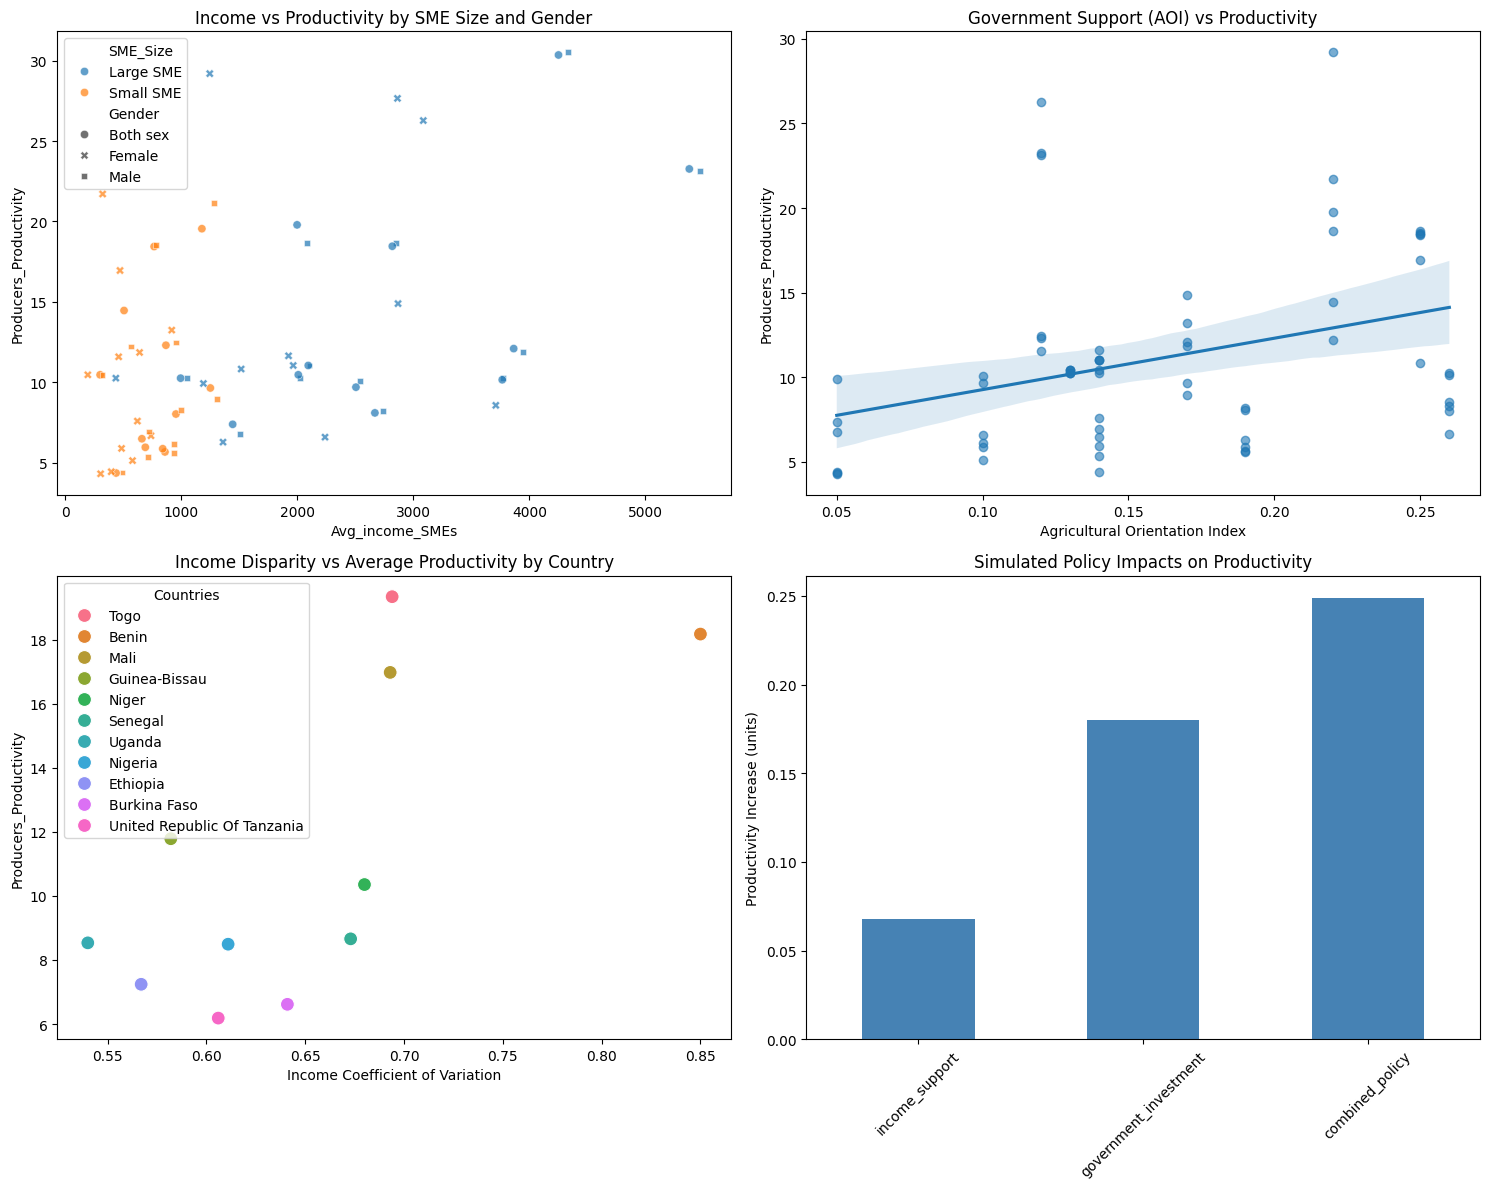

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

#1. Income vs Productivity by SME Size
sns.scatterplot(
    x='Avg_income_SMEs',
    y='Producers_Productivity',
    hue='SME_Size',
    style='Gender',
    data=merged_df,
    ax=axes[0, 0],
    alpha=0.7
)
axes[0, 0].set_title('Income vs Productivity by SME Size and Gender')

#2. Government Support vs Productivity
sns.regplot(
    x='AOI',
    y='Producers_Productivity',
    data=merged_df,
    ax=axes[0, 1],
    scatter_kws={'alpha': 0.6}
)
axes[0, 1].set_title('Government Support (AOI) vs Productivity')
axes[0, 1].set_xlabel('Agricultural Orientation Index')

#3. Income Disparity vs Average Productivity
sns.scatterplot(
    x='income_cv',
    y='Producers_Productivity',
    hue=country_performance.index,
    data=country_performance,
    ax=axes[1, 0],
    s=100
)
axes[1, 0].set_title('Income Disparity vs Average Productivity by Country')
axes[1, 0].set_xlabel('Income Coefficient of Variation')

#4. Policy Impact Comparison
pd.Series(policy_impacts).plot(kind='bar', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Simulated Policy Impacts on Productivity')
axes[1, 1].set_ylabel('Productivity Increase (units)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Policy Recommendations Framework**

In [ ]:
#Generating targeted recommendations
def generate_recommendations(model_results, country_data):
    recommendations = []

    #Income disparity findings
    income_effect = model_results.params['Avg_income_SMEs']
    if income_effect > 0:
        recommendations.append(
            "INCOME SUPPORT: Direct income interventions likely to boost productivity "
            f"(estimated effect: {income_effect:.3f} units per income unit)"
        )

    #Government support findings
    aoi_effect = model_results.params['AOI']
    if aoi_effect > 0:
        recommendations.append(
            "GOVERNMENT INVESTMENT: Increased agricultural budget allocation effective "
            f"(estimated effect: {aoi_effect:.3f} units per AOI point)"
        )

    #Size-specific recommendations
    sme_size_effects = model_results.params[model_results.params.index.str.contains('SME_Size')]
    for effect in sme_size_effects.items():
        recommendations.append(
            f"TARGETED SUPPORT: {effect[0]} shows significant impact "
            f"(coefficient: {effect[1]:.3f})"
        )

    return recommendations

#Generate and display recommendations
policy_recommendations = generate_recommendations(model, country_performance)
print("\n=== EVIDENCE-BASED POLICY RECOMMENDATIONS ===")
for i, rec in enumerate(policy_recommendations, 1):
    print(f"{i}. {rec}")


=== EVIDENCE-BASED POLICY RECOMMENDATIONS ===
1. INCOME SUPPORT: Direct income interventions likely to boost productivity (estimated effect: 0.002 units per income unit)
2. GOVERNMENT INVESTMENT: Increased agricultural budget allocation effective (estimated effect: 0.059 units per AOI point)
3. TARGETED SUPPORT: Avg_income_SMEs:C(SME_Size)[T.Small SME] shows significant impact (coefficient: 0.000)
4. TARGETED SUPPORT: AOI:C(SME_Size)[T.Small SME] shows significant impact (coefficient: 8.853)
